In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import glob
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from scipy.interpolate import PchipInterpolator,interp1d
from scipy.integrate import quad
from scipy.stats import linregress
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov_nu
import kuibit.simdir as SD
import re
import h5py as h5


Define physical constants and conversion factors

In [2]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2
hc = 197.3 #hbar c Mev fm

#Nuclear Physics Parameters
n0 = 0.16
mn = 939.56

#TOV Solver parameters

epsilon = mn*n0 #TOV solver energy scale

#Conversion Factors
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
meters_to_msol = geometrized_to_SI/(1.989*10**30)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
freq_code_u_to_hz = 203000
time_code_u_to_ms = 1/203
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
geometrized_code_to_nb_n0 = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)

Create RVSS-$\alpha$ models 
|Model|$\alpha\text{ (MeV}^{-1})$|
|-----|--------|
|A    |0.003985|
|B    |0.002112|
|C    |0.001710|
|D    |0.001239|
|E    |0.002761|



In [3]:
Alpha_A = rvss_eos(1200,mu_max=2700)
Alpha_E = rvss_eos(1300,mu_max=2700)
Alpha_B = rvss_eos(1400,mu_max=2700)
Alpha_C = rvss_eos(1500,mu_max=2700)
Alpha_D = rvss_eos(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


Create solvers for each model

In [4]:
Alpha_A_Solver = tov_nu(epsilon,lambda p: Alpha_A.eos_interp(p*epsilon)/epsilon,lambda p: Alpha_A.nb_interp(p*epsilon))
Alpha_B_Solver = tov_nu(epsilon,lambda p: Alpha_B.eos_interp(p*epsilon)/epsilon,lambda p: Alpha_B.nb_interp(p*epsilon))
Alpha_C_Solver = tov_nu(epsilon,lambda p: Alpha_C.eos_interp(p*epsilon)/epsilon,lambda p: Alpha_C.nb_interp(p*epsilon))
Alpha_D_Solver = tov_nu(epsilon,lambda p: Alpha_D.eos_interp(p*epsilon)/epsilon,lambda p: Alpha_D.nb_interp(p*epsilon))
Alpha_E_Solver = tov_nu(epsilon,lambda p: Alpha_E.eos_interp(p*epsilon)/epsilon,lambda p: Alpha_E.nb_interp(p*epsilon))

RVSS_Solvers = {'V': Alpha_A_Solver,
                'III': Alpha_B_Solver,
                'II': Alpha_C_Solver,
                'I': Alpha_D_Solver,
                'IV': Alpha_E_Solver}

RVSS_List = {"V" : [Alpha_A,'red',0.0039],  
             "IV" : [Alpha_E,'purple',0.0027],
             "III" : [Alpha_B,'blue',0.0021],
             "II": [Alpha_C,'green',0.0017],
             "I": [Alpha_D,'black',0.0012]}   #List for plotting 

In [5]:
core_db_path = 'coreDB/THC_DB/THC/DB'
core_db_eos_path = 'coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

FileNotFoundError: [Errno 2] No such file or directory: 'coreDB/THC_DB/THC/DB'

In [5]:
eos_colors = {"BA": "red",
              "SLy": "blue",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              "MS1b": "magenta"}

In [6]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}

eos_alpha = {}
eos_beta = {}
eos_interp = {}
dens_interp = {}
alpha_interp = {}
beta_interp = {}
eos_mub_interp = {}

eos_cs2_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3): continue
            else:
                eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
                eos_cs2[eos_name] = eos_data[:,3]
                eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
                eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
                eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])
    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name],eos_cs2[eos_name],fill_value='extrapolate')
    eos_beta[eos_name] = np.gradient(eos_cs2[eos_name],eos_dens[eos_name])
    eos_alpha[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name],eos_eden[eos_name])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name],eos_dens[eos_name])
    alpha_interp[eos_name] = interp1d(eos_press[eos_name],eos_alpha[eos_name],fill_value='extrapolate')
    beta_interp[eos_name] = interp1d(eos_press[eos_name],eos_beta[eos_name],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name],eos_mub[eos_name],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov_nu(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        bary_density= lambda p: dens_interp[eos_i](p * epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [11]:
plt.plot(RVSS_List["A"][0].nb_unified/n0,RVSS_List["A"][0].cs2_unified,color=RVSS_List["A"][1],linestyle='--',label='EOS-V')
plt.plot(RVSS_List["E"][0].nb_unified/n0,RVSS_List["E"][0].cs2_unified,color=RVSS_List["E"][1],linestyle='--',label='EOS-IV')
plt.plot(RVSS_List["B"][0].nb_unified/n0,RVSS_List["B"][0].cs2_unified,color=RVSS_List["B"][1],linestyle='--',label='EOS-III')
plt.plot(RVSS_List["C"][0].nb_unified/n0,RVSS_List["C"][0].cs2_unified,color=RVSS_List["C"][1],linestyle='--',label='EOS-II')
plt.plot(RVSS_List["D"][0].nb_unified/n0,RVSS_List["D"][0].cs2_unified,color=RVSS_List["D"][1],linestyle='--',label='EOS-I')

for eos in eos_dens:
    plt.plot(eos_dens[eos]/n0,eos_cs2[eos],label=eos,color=eos_colors[eos])

plt.xlim([0,4])
plt.xlabel(r'$n/n_0$')
plt.ylabel(r'$(c_s/c)^2$')

plt.legend()

# plt.savefig('./Figures/Final_Paper_Figs/ALPHA_cs2_n_core.pdf',format='pdf',dpi=300)

KeyError: 'A'

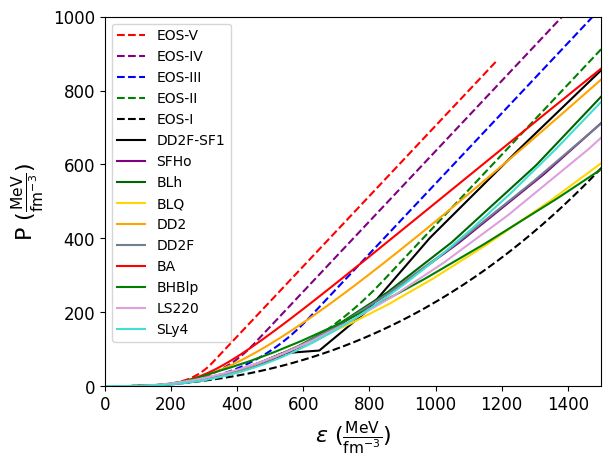

In [13]:
plt.plot(RVSS_List["V"][0].E_unified,RVSS_List["V"][0].P_unified,color = RVSS_List["V"][1],linestyle='--',label="EOS-V")
plt.plot(RVSS_List["IV"][0].E_unified,RVSS_List["IV"][0].P_unified,color = RVSS_List["IV"][1],linestyle='--',label="EOS-IV")
plt.plot(RVSS_List["III"][0].E_unified,RVSS_List["III"][0].P_unified,color = RVSS_List["III"][1],linestyle='--',label="EOS-III")
plt.plot(RVSS_List["II"][0].E_unified,RVSS_List["II"][0].P_unified,color = RVSS_List["II"][1],linestyle='--',label="EOS-II")
plt.plot(RVSS_List["I"][0].E_unified,RVSS_List["I"][0].P_unified,color = RVSS_List["I"][1],linestyle='--',label="EOS-I")

for eos in eos_eden:
    plt.plot(eos_eden[eos],eos_press[eos],label=eos,color=eos_colors[eos])
plt.xlim([0,1500])
plt.ylim([0,1000])
plt.ylabel(r"$\text{P }(\frac{\text{MeV}}{\text{fm}^{-3}})$")
plt.xlabel(r"$\varepsilon \text{ }(\frac{\text{MeV}}{\text{fm}^{-3}})$")
plt.legend()

# plt.savefig('./Figures/Final_Paper_Figs/eos_p_vs_e.pdf',format = 'pdf')


In [11]:
def ns_vol_avg(q_interp ,sol, r_stop):
    M_r = sol.y[1,:]
    rad = sol.t
    M_r_interp = interp1d(rad,M_r,fill_value='extrapolate')
    def vol_integrand(r):
        return 4*np.pi*r**(2)*(1 - 2*(1.476)*M_r_interp(r)/r)**(-1/2)
    def vol_avg_integrand(r):
        return q_interp(r)*vol_integrand(r)
    
    Vol = quad(vol_integrand,a=0,b=r_stop)[0]
    Vol_avg_integral = quad(vol_avg_integrand,a=0,b=r_stop)[0]
    return Vol_avg_integral/Vol

In [7]:
NS_mass_grav = {}
NS_mass_bary = {}
NS_radius = {}

NS_alpha_c = {}
NS_nb_c = {}
NS_cs2_c = {}
NS_mub_c = {}

NS_cs2_mub_vavg = {}
NS_mu_alpha_vavg = {}
NS_cs2_vavg = {}
NS_nb_beta_vavg = {}

NS_m_cs2_mub_vavg_interp = {}
NS_m_alpha_mu_vavg_interp = {}

NS_alpha_interp = {}
NS_cs2_c_interp = {}
NS_mub_c_interp = {}
NS_pc_interp = {}
NS_nb_c_interp = {}
NS_radius_interp = {}
NS_cs2_vavg_interp = {}

NS_max_mass = {}
p_mesh = np.logspace(-2,np.log10(5),100)

for eos_name in eos_interp.keys():
    file_name = f'{eos_name}_MVR.txt'
    file_path = os.path.join(os.path.abspath('MVR/CORE'),file_name)

    NS_mass_grav[eos_name] = np.empty_like(p_mesh)
    NS_mass_bary[eos_name] = np.empty_like(p_mesh)
    NS_radius[eos_name] = np.empty_like(p_mesh)
    NS_alpha_c[eos_name] = np.empty_like(p_mesh)
    NS_nb_c[eos_name] = np.empty_like(p_mesh)
    NS_cs2_c[eos_name] = np.empty_like(p_mesh)
    NS_mub_c[eos_name] = np.empty_like(p_mesh)
    NS_cs2_mub_vavg[eos_name] = np.empty_like(p_mesh)
    NS_mu_alpha_vavg[eos_name] = np.empty_like(p_mesh)
    NS_cs2_vavg[eos_name] = np.empty_like(p_mesh)
    #NS_nb_beta_vavg[eos_name] = np.empty_like(p_mesh)
    if not os.path.isfile(file_path):
        print(f'MVR file not found Preparing MvR for {eos_name}')
        for i,p in enumerate(p_mesh):
            sol,nu = solver_list[eos_name].solve_nu(p,dr=0.001,r_max= 20)

            NS_mass_grav[eos_name][i] = sol.y[1,-1]
            NS_radius[eos_name][i] = sol.t[-1]
            NS_alpha_c[eos_name][i] = alpha_interp[eos_name](p*epsilon)
            NS_nb_c[eos_name][i] = dens_interp[eos_name](p*epsilon)
            NS_cs2_c[eos_name][i] = eos_cs2_interp[eos_name](p*epsilon)
            NS_mub_c[eos_name][i] = (p*epsilon + eos_interp[eos_name](p*epsilon))/(dens_interp[eos_name](p*epsilon))

            #Calculate the volume averaged cs2/mu
            r = sol.t
            p_r = sol.y[0,:]
            NS_mub_r = interp1d(sol.t,eos_mub_interp[eos_name](p_r*epsilon),fill_value='extrapolate')
            NS_nb_r = interp1d(dens_interp[eos_name](p_r*epsilon),sol.t,fill_value='extrapolate')
            NS_cs2_r = interp1d(sol.t,eos_cs2_interp[eos_name](p_r*epsilon),fill_value='extrapolate')

            NS_cs2_mub_r = interp1d(sol.t,eos_cs2_interp[eos_name](p_r*epsilon)/(eos_mub_interp[eos_name](p_r*epsilon)),fill_value='extrapolate')
            NS_alpha_r = interp1d(sol.t,alpha_interp[eos_name](p_r*epsilon),fill_value='extrapolate')
            NS_mu_alpha_r = interp1d(sol.t,NS_mub_r(sol.t)*NS_alpha_r(sol.t),fill_value='extrapolate')
            NS_beta_nb_r = interp1d(sol.t,beta_interp[eos_name](p_r*epsilon)*NS_nb_r(sol.t),fill_value='extrapolate')


            r_stop = NS_nb_r((2.0/3.0)*NS_nb_c[eos_name][i])

            NS_cs2_vavg[eos_name][i] = solver_list[eos_name].ns_vol_avg(NS_cs2_r,r_stop,solution=sol,nu_sol=nu)
            NS_cs2_mub_vavg[eos_name][i] = solver_list[eos_name].ns_vol_avg(NS_cs2_mub_r,r_stop,solution=sol,nu_sol=nu)
            NS_mu_alpha_vavg[eos_name][i] = solver_list[eos_name].ns_vol_avg(NS_mu_alpha_r,r_stop,solution=sol,nu_sol=nu)
        
            


            print(f'M: {sol.y[1,-1]}        R: {sol.t[-1]}      nb_c:{dens_interp[eos_name](p*epsilon)}'
                f'      alpha_c: {NS_alpha_c[eos_name][i]:.3e}    cs2_c: {NS_cs2_c[eos_name][i]:.3e}'
                f'      mu_c: {NS_mub_c[eos_name][i]:.3e} MeV'
                f'      (cs2/mu)avg: {NS_cs2_mub_vavg[eos_name][i]} MeV^-1     (alpha*mu)avg: {NS_mu_alpha_vavg[eos_name][i]}')
        
        mvr_data_out = np.column_stack((NS_mass_grav[eos_name],
                                        NS_radius[eos_name],
                                        NS_nb_c[eos_name],
                                        NS_alpha_c[eos_name],
                                        NS_cs2_c[eos_name],
                                        NS_mub_c[eos_name],
                                        NS_cs2_mub_vavg[eos_name],
                                        NS_mu_alpha_vavg[eos_name],
                                        NS_cs2_vavg[eos_name],))
        
        np.savetxt(file_path,mvr_data_out,header='M(M_sol)  ' \
        'R(km)   ' \
        'nb_c(fm^-3)   ' \
        'Alpha_C(MeV^-1)     ' \
        'cs2_c   ' \
        'mu_c(MeV)' \
        'cs2_mubm1_Vavg' \
        'cs2_mu_cs2prime_Vavg' \
        'NS_cs2_vAvg' )
    else:
        print(f'Reading MVR file for {eos_name}')
        mvr_data_in = np.loadtxt(file_path,skiprows=1)
        NS_mass_grav[eos_name] = mvr_data_in[:,0]
        NS_radius[eos_name] = mvr_data_in[:,1]
        NS_nb_c[eos_name] = mvr_data_in[:,2]
        NS_alpha_c[eos_name] = mvr_data_in[:,3]
        NS_cs2_c[eos_name] = mvr_data_in[:,4]
        NS_mub_c[eos_name] = mvr_data_in[:,5]
        NS_cs2_mub_vavg[eos_name] = mvr_data_in[:,6]
        NS_mu_alpha_vavg[eos_name] = mvr_data_in[:,7]
        NS_cs2_vavg[eos_name] = mvr_data_in[:,8]
        
    NS_max_mass[eos_name] = np.max(NS_mass_grav[eos_name])
    NS_alpha_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_alpha_c[eos_name],fill_value='extrapolate')
    NS_cs2_c_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_cs2_c[eos_name],fill_value='extrapolate')
    NS_mub_c_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_mub_c[eos_name],fill_value='extrapolate')
    NS_pc_interp[eos_name] = interp1d(NS_mass_grav[eos_name],p_mesh,fill_value='extrapolate')
    NS_nb_c_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_nb_c[eos_name],fill_value='extrapolate')
    NS_m_cs2_mub_vavg_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_cs2_mub_vavg[eos_name],fill_value='extrapolate')
    NS_m_alpha_mu_vavg_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_mu_alpha_vavg[eos_name],fill_value='extrapolate')
    NS_radius_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_radius[eos_name],fill_value='extrapolate')
    NS_cs2_vavg_interp[eos_name] = interp1d(NS_mass_grav[eos_name],NS_cs2_vavg[eos_name])

Reading MVR file for DD2F-SF1
MVR file not found Preparing MvR for SFHo
M: 0.16082248824986062        R: 19.030911440468262      nb_c:0.1268512424925185      alpha_c: 1.516e-03    cs2_c: 2.647e-02      mu_c: 9.728e+02 MeV      (cs2/mu)avg: 2.0636277899502984e-05 MeV^-1     (alpha*mu)avg: 1.1023146589541315
M: 0.16609500262396043        R: 18.526063109940647      nb_c:0.13058107973268634      alpha_c: 1.583e-03    cs2_c: 2.767e-02      mu_c: 9.735e+02 MeV      (cs2/mu)avg: 2.1324967646113408e-05 MeV^-1     (alpha*mu)avg: 1.1392830787635166
M: 0.17153494530009325        R: 18.057679711713213      nb_c:0.13437616787841916      alpha_c: 1.655e-03    cs2_c: 2.893e-02      mu_c: 9.743e+02 MeV      (cs2/mu)avg: 2.2058084253429193e-05 MeV^-1     (alpha*mu)avg: 1.1800768210673578
M: 0.17715612956891186        R: 17.615562037676252      nb_c:0.1382032613265516      alpha_c: 1.731e-03    cs2_c: 3.028e-02      mu_c: 9.751e+02 MeV      (cs2/mu)avg: 2.2833801457881347e-05 MeV^-1     (alpha*mu)avg: 1

/home/john/PhD_Projects/High_Density_Sound_Speed/Modules/TOV_Solver_RK45.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Vol_avg_integral = quad(vol_avg_integrand,a=0.001,b=r_stop)[0]


M: 0.24698152465227494        R: 14.591277648539899      nb_c:0.17882615634181623      alpha_c: 2.222e-03    cs2_c: 5.094e-02      mu_c: 9.851e+02 MeV      (cs2/mu)avg: 3.403503559512057e-05 MeV^-1     (alpha*mu)avg: 1.751288659365742
M: 0.25572916607531737        R: 14.39072280457788      nb_c:0.1831075919037701      alpha_c: 2.253e-03    cs2_c: 5.378e-02      mu_c: 9.863e+02 MeV      (cs2/mu)avg: 3.559533672446628e-05 MeV^-1     (alpha*mu)avg: 1.8039659741549328
M: 0.2648798045784742        R: 14.200252570976486      nb_c:0.18739960971300132      alpha_c: 2.285e-03    cs2_c: 5.680e-02      mu_c: 9.875e+02 MeV      (cs2/mu)avg: 3.7236794643661406e-05 MeV^-1     (alpha*mu)avg: 1.8545352516799747
M: 0.2744624463658308        R: 14.019678884199443      nb_c:0.19168141690844914      alpha_c: 2.314e-03    cs2_c: 5.996e-02      mu_c: 9.889e+02 MeV      (cs2/mu)avg: 3.89610195133075e-05 MeV^-1     (alpha*mu)avg: 1.9028420883440793
M: 0.28450531677427743        R: 13.849492783612895      nb_c

/home/john/PhD_Projects/High_Density_Sound_Speed/Modules/TOV_Solver_RK45.py:88: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Vol_avg_integral = quad(vol_avg_integrand,a=0.001,b=r_stop)[0]


M: 1.1053484191443976        R: 12.010538984602091      nb_c:0.4178310974262659      alpha_c: 1.441e-03    cs2_c: 2.888e-01      mu_c: 1.115e+03 MeV      (cs2/mu)avg: 0.00018585434655744225 MeV^-1     (alpha*mu)avg: 1.8558410754952717
M: 1.1386933761213271        R: 12.008242392920117      nb_c:0.42658982265302375      alpha_c: 1.420e-03    cs2_c: 2.974e-01      mu_c: 1.122e+03 MeV      (cs2/mu)avg: 0.000191984427803896 MeV^-1     (alpha*mu)avg: 1.8319259876567386
M: 1.1722374551411745        R: 12.000768929054784      nb_c:0.43558635200587276      alpha_c: 1.397e-03    cs2_c: 3.067e-01      mu_c: 1.129e+03 MeV      (cs2/mu)avg: 0.00019821468283348428 MeV^-1     (alpha*mu)avg: 1.8083770999929842
M: 1.2059238056331045        R: 11.987891434182258      nb_c:0.4448119897054286      alpha_c: 1.373e-03    cs2_c: 3.165e-01      mu_c: 1.137e+03 MeV      (cs2/mu)avg: 0.00020452330086034675 MeV^-1     (alpha*mu)avg: 1.7853840610463394
M: 1.2396965490505472        R: 11.98049062165543      nb_c:

/home/john/PhD_Projects/High_Density_Sound_Speed/Modules/TOV_Solver_RK45.py:87: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Vol = quad(vol_integrand,a=0.001,b=r_stop)[0]


M: 2.063340806057981        R: 10.39950225661553      nb_c:1.1106081593277333      alpha_c: 3.634e-04    cs2_c: 7.832e-01      mu_c: 1.897e+03 MeV      (cs2/mu)avg: 0.0004181204512482209 MeV^-1     (alpha*mu)avg: 0.7437017049900061
M: 2.063828356216733        R: 10.330808011199455      nb_c:1.1390570214312956      alpha_c: 3.619e-04    cs2_c: 7.965e-01      mu_c: 1.935e+03 MeV      (cs2/mu)avg: 0.0004185257957868746 MeV^-1     (alpha*mu)avg: 0.7285667974429699
M: 2.0633692460769595        R: 10.268147578508092      nb_c:1.1682234164913987      alpha_c: 3.603e-04    cs2_c: 8.107e-01      mu_c: 1.974e+03 MeV      (cs2/mu)avg: 0.0004185720166615049 MeV^-1     (alpha*mu)avg: 0.7173486047795677
MVR file not found Preparing MvR for BLh
M: 0.16420068114979597        R: 18.397099991872714      nb_c:0.12283637430125063      alpha_c: 2.359e-03    cs2_c: 3.492e-02      mu_c: 9.726e+02 MeV      (cs2/mu)avg: 2.1325630477932086e-05 MeV^-1     (alpha*mu)avg: 2.303542251343473
M: 0.1701551238324912   

In [13]:
mvr_data_in = np.loadtxt('./coreDB/THC_DB/THC/DB/EOS/SLy/TOV.dat',skiprows=1)
eos_name = "SLy"

NS_mass[eos_name] = mvr_data_in[:,1]
NS_radius[eos_name] = mvr_data_in[:,3]*1.47

mvr_data_in = np.loadtxt('./coreDB/THC_DB/THC/DB/EOS/MS1b/TOV.dat',skiprows=1)
eos_name = "MS1b"

NS_mass[eos_name] = mvr_data_in[:,1]
NS_radius[eos_name] = mvr_data_in[:,3]*1.47



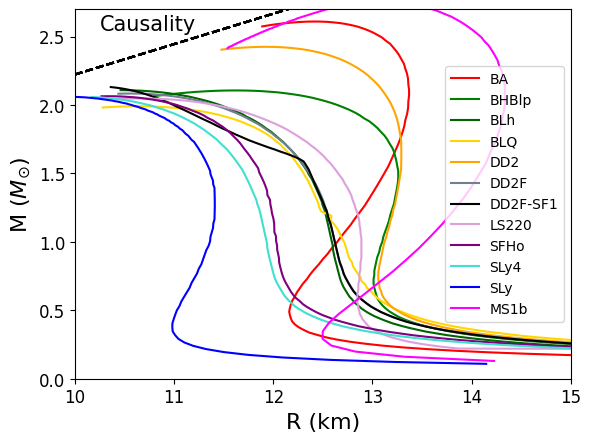

In [14]:
r_causailty = np.linspace(10,15,100)
m_causality = r_causailty/4.5
for eos in NS_mass:
    M = NS_mass[eos]
    R = NS_radius[eos]

    plt.plot(R,M,label=eos,color=eos_colors[eos])
    plt.plot(r_causailty,m_causality,linestyle='--',color = 'black')
plt.legend()
plt.xlim([10,15])
plt.ylabel(r'$\text{M }(M_{\odot})$')
plt.xlabel(r'R (km)')
plt.ylim([0,2.7])
plt.text(10.25,2.55,"Causality",fontsize=15)
plt.savefig('./Figures/T2 Seminar Figs/MVR_Core.pdf',format='pdf')
plt.show()



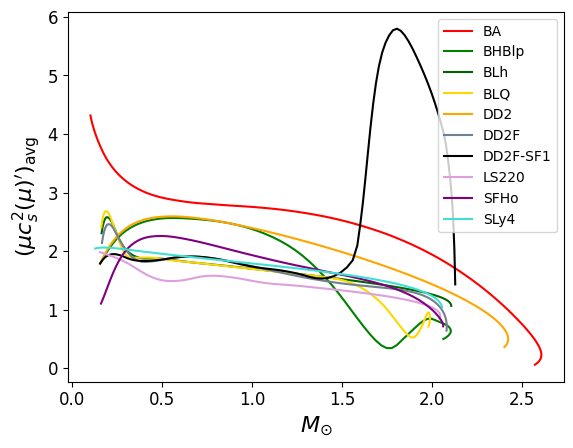

In [27]:
for eos in eos_interp.keys():
    plt.plot(NS_mass[eos],NS_mu_alpha_vavg[eos],label=eos,color=eos_colors[eos])

plt.xlabel(r'$M_{\odot}$')
plt.ylabel(r"$(\mu c_s^2(\mu)')_{\text{avg}}$")
plt.legend()

for eos in eos_interp.keys():
    dataout = np.column_stack([NS_mass[eos],NS_mu_alpha_vavg[eos]])
    np.savetxt(f'./Figure_Data/CORE/{eos}_mu_cs2prime.txt',dataout)

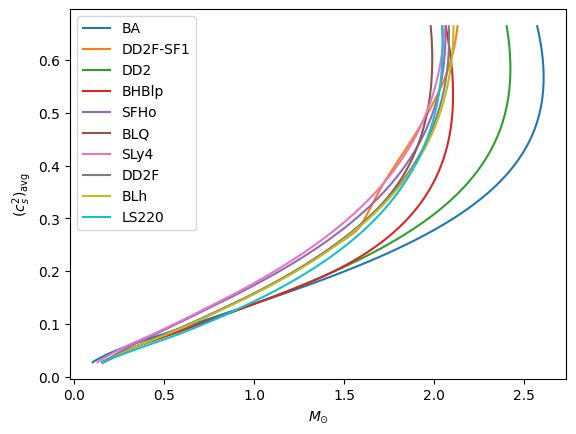

In [12]:
for eos in eos_interp.keys():
    plt.plot(NS_mass[eos],NS_cs2_vavg[eos_name],label=eos)
plt.xlabel(r'$M_{\odot}$')
plt.ylabel(r'$(c_s^2)_{\text{avg}}$')
plt.legend()

dict_keys(['BA', 'BHBlp', 'BLh', 'BLQ', 'DD2', 'DD2F', 'DD2F-SF1', 'LS220', 'SFHo', 'SLy4'])


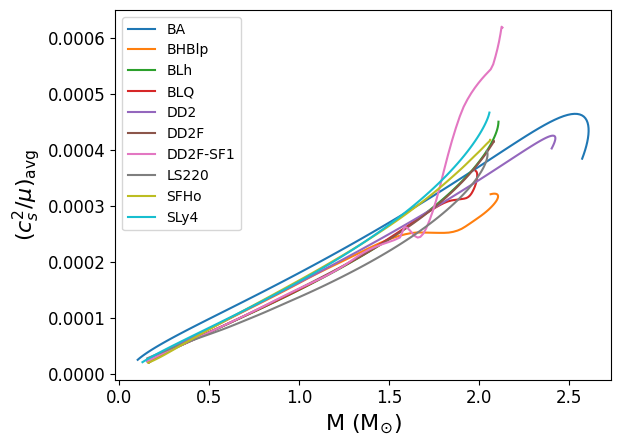

In [26]:
for eos in eos_interp.keys():
    plt.plot(NS_mass[eos],NS_cs2_mub_vavg[eos],label=eos)

plt.xlabel(r'$\text{M }(\text{M}_{\odot})$')
plt.ylabel(r'$(c_s^2/\mu)_{\text{avg}}$')
plt.legend()
print(eos_interp.keys())
for eos in eos_interp.keys():
    dataout = np.column_stack([NS_mass[eos],NS_cs2_mub_vavg[eos]])
    np.savetxt(f'./Figure_Data/CORE/{eos}_cs2_mu.txt',dataout)

In [ ]:
NS_Alpha_Mass = {}
NS_Alpha_Radius = {}
NS_Alpha_nb_c = {}
NS_Alpha_cs2_c = {}
NS_Alpha_mub_c = {}
NS_Alpha_cs2_mub_Vavg = {}
NS_Alpha_mub_cs2p_Vavg = {}

NS_RVSS_cs2_c_interp = {}
NS_RVSS_mub_c_interp = {}
NS_RVSS_pc_interp = {}
NS_RVSS_radius_interp = {}

p_mesh = np.logspace(-2,np.log10(5),100)
for model in RVSS_Solvers.keys():

    file_name = f'{model}_MVR.txt'
    file_path = os.path.join(os.path.abspath('MVR/RVSS'),file_name)
    NS_Alpha_Mass[model] = np.empty_like(p_mesh)
    NS_Alpha_Radius[model] = np.empty_like(p_mesh)
    NS_Alpha_nb_c[model] = np.empty_like(p_mesh)
    NS_Alpha_cs2_c[model] = np.empty_like(p_mesh)
    NS_Alpha_mub_c[model] = np.empty_like(p_mesh)
    NS_Alpha_cs2_mub_Vavg = np.empty_like(p_mesh)
    NS_Alpha_mub_cs2p_Vavg = np.empty_like(p_mesh)
    

    NS_RVSS_cs2priime = np.gradient(RVSS_List[model][0].cs2_unified,RVSS_List[model][0].chem_pot_unified)
    NS_RVSS_cs2prime_p_interp = interp1d(RVSS_List[model][0].P_unified,NS_RVSS_cs2priime)
    if True:
        for i,p in enumerate(p_mesh):
            sol,nu = RVSS_Solvers[model].solve_nu(p,0.001,30)
            NS_Alpha_Mass[model][i] = sol.y[1,-1]
            NS_Alpha_Radius[model][i] = sol.t[-1]
            NS_Alpha_nb_c[model][i] = RVSS_List[model].nb_interp(p*epsilon)
            NS_Alpha_cs2_c[model][i] = RVSS_List[model].cs2_nb(RVSS_List[model].nb_interp(p*epsilon))
            NS_Alpha_mub_c[model][i] = (p*epsilon + RVSS_List[model].eos_interp(p*epsilon))/(RVSS_List[model].nb_interp(p*epsilon))

            
            NS_RVSS_cs2_c_interp[model] = interp1d(NS_Alpha_Mass[model],NS_Alpha_cs2_c[model],fill_value='extrapolate')
            NS_RVSS_mub_c_interp[model] = interp1d(NS_Alpha_Mass[model],NS_Alpha_mub_c[model],fill_value='extrapolate')
            NS_RVSS_pc_interp[model] = interp1d(NS_Alpha_Mass[model],p_mesh*epsilon,fill_value='extrapolate')
            NS_RVSS_radius_interp[model] = interp1d(NS_Alpha_Mass[model],NS_Alpha_Radius[model],fill_value='extrapolate')

            mub_r = (RVSS_List[model][0].eos_interp(sol.y[0]*epsilon) + sol.y[0]*epsilon)/(RVSS_List[model][0].nb_interp(sol.y[0]*epsilon))
            
            NS_RVSS_nb_r = interp1d(sol.t,RVSS_List[model][0].nb_interp(sol.y[0]*epsilon))
            NS_RVSS_cs2_mub_r = interp1d(sol.t,RVSS_List[model][0].cs2_interp(sol.y[0]*epsilon)/mub_r)
            NS_RVSS_mub_cs2p_r = interp1d(sol.t,NS_RVSS_cs2prime_p_interp(sol.y[0]*epsilon))



            r_stop = NS_RVSS_nb_r((2.0/3.0)*NS_Alpha_nb_c[model][i])

            NS_Alpha_cs2_mub_Vavg[model][i] = RVSS_Solvers[model].ns_vol_avg(NS_cs2_mub_r,r_stop,solution=sol,nu_sol=nu)
            NS_Alpha_mub_cs2p_Vavg[model][i] = RVSS_Solvers[model].ns_vol_avg(NS_mu_alpha_r,r_stop,solution=sol,nu_sol=nu)
            
            
            print(f'M: {sol.y[1,-1]}        R: {sol.t[-1]}\n'
                f'      pc: {p:.3f}'
                f'      NS_alpha_cs2_mub_Vavg {NS_Alpha_cs2_mub_Vavg[model][i]}'
                f'      NS_alpha_cs2p {NS_Alpha_mub_cs2p_Vavg[model][i]}')
        rvss_mvr_out = np.column_stack((NS_Alpha_Mass[model],
                                        NS_Alpha_Radius[model],
                                        NS_Alpha_nb_c[model],
                                        NS_Alpha_cs2_c[model],
                                        NS_Alpha_mub_c[model],
                                        NS_Alpha_cs2_mub_Vavg[model],
                                        NS_Alpha_mub_cs2p_Vavg[model]
                                        ))
        np.savetxt(file_path,rvss_mvr_out,header='M(MSol)        R(km)       nb_c(fm^-3)     cs2_c       mub_c(fm^-3) cs2_mub_Vavg  mub_cs2p_Vavg')
    

NameError: name 'np' is not defined

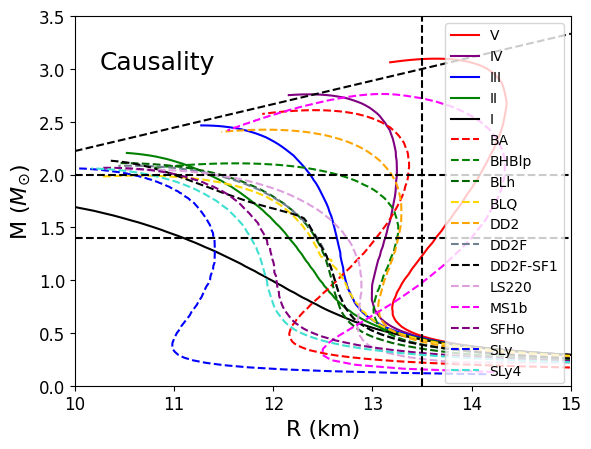

In [16]:
r_causailty = np.linspace(10,15,100)
m_causality = r_causailty/4.5
for model in RVSS_List:
    M = NS_Alpha_Mass[model]
    R = NS_Alpha_Radius[model]

    plt.plot(R,M,label=model,color=RVSS_List[model][1])
plt.plot(r_causailty,m_causality,linestyle='--',color = 'black')
for eos in eos_list:
    M = NS_mass[eos]
    R = NS_radius[eos]
    plt.plot(R,M,label=eos,color=eos_colors[eos],linestyle='--')
plt.legend()
plt.xlim([10,15])
plt.ylabel(r'$\text{M }(M_{\odot})$')
plt.xlabel(r'R (km)')
plt.ylim([0,3.5])
plt.text(10.25,3.0,"Causality",fontsize=18)
plt.axhline(y=2.0,linestyle='--',color = 'black')
plt.axhline(y=1.4,linestyle='--',color = 'black')
plt.axvline(x=13.5,linestyle='--',color='black')
# plt.savefig('./Figures/Final_Paper_Figs/MVR_RVSS.pdf',format='pdf')
plt.show()


In [17]:
kb_sim_dirs = {}

for eos in sim_names:
    kb_sim_dirs[eos] = SD.SimDir(os.path.abspath(os.path.join(core_db_path,eos)))
p_cut = 600

core_db_strain = {}
core_db_gws = {}
core_db_gw_phase = {}
core_db_gw_inst_freq = {}
core_db_gw_asd = {}
core_db_gw_htilde = {}

core_fpeak = {}

for sim_name in kb_sim_dirs:
    sd = kb_sim_dirs[sim_name]
    core_db_strain[sim_name] = {}
    core_db_gws[sim_name] = {}
    for gw in sd.gws:
        extr_radius = str(gw.radius)
        core_db_gws[sim_name][extr_radius] = gw
        strain = gw.get_strain_lm(2,
                                2,
                                p_cut,
                                0.1,
                                window_function='tukey')
        core_db_strain[sim_name][extr_radius] = strain

for sim in core_db_strain:
    core_db_gw_phase[sim] = {}
    core_db_gw_inst_freq[sim] = {}
    for r in core_db_strain[sim]:
        time = core_db_strain[sim][r].t
        real_h = np.real(core_db_strain[sim][r].y)
        imag_h = np.imag(core_db_strain[sim][r].y)
        phase = np.unwrap(np.arctan2(real_h,imag_h))
        
        core_db_gw_phase[sim][r] = phase
        core_db_gw_inst_freq[sim][r] = (1/(2*np.pi))*np.gradient(phase,time)
    
    core_db_gw_asd[sim] = {}
    core_db_gw_htilde[sim] = {}
    for r in core_db_strain[sim]:
        h_plus = core_db_strain[sim][r].real()
        h_cross = core_db_strain[sim][r].imag()

        h_plus_tilde = h_plus.to_FrequencySeries()
        h_cross_tilde = h_cross.to_FrequencySeries()

        h_tilde = np.sqrt((h_plus_tilde.real()**2 + h_plus_tilde.imag()**2) + (h_cross_tilde.real()**2 + h_cross_tilde.imag()**2))
        core_db_gw_htilde[sim][r] = h_tilde
        core_db_gw_asd[sim][r] = 2.0*h_tilde.fft*np.sqrt(h_tilde.f*freq_code_u_to_hz)
    core_fpeak[sim] = core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])]*freq_code_u_to_hz/1000

    sim_info[sim]['Mfpeak'] = (core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])])*(sim_info[sim]['m_total'])
    sim_info[sim]['fpeak'] = core_fpeak[sim]


<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>


/home/john/.local/lib/python3.10/site-packages/kuibit/timeseries.py:769: RuntimeWarning: TimeSeries is not regularly samples. Resampling.
  warnings.warn(


<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0x77e1a2b31510>
<function tukey at 0

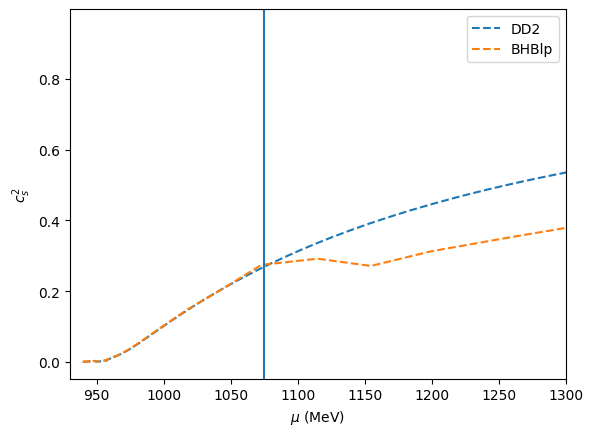

In [11]:

plt.plot(eos_mub['DD2'],eos_cs2['DD2'],label='DD2',linestyle='--')  
plt.plot(eos_mub['BHBlp'],eos_cs2['BHBlp'],label='BHBlp',linestyle='--')
# for alpha in RVSS_List:
#     plt.plot(RVSS_List[alpha][0].nb_unified/n0,RVSS_List[alpha][0].cs2_unified,label=f'Alpha {alpha}',color=RVSS_List[alpha][1])
plt.legend()
plt.xlim([930,1300])
plt.xlabel(r'$\mu \text{ (MeV)}$')
plt.ylabel(r'$c_s^2$')
plt.axvline(1075)
plt.show()

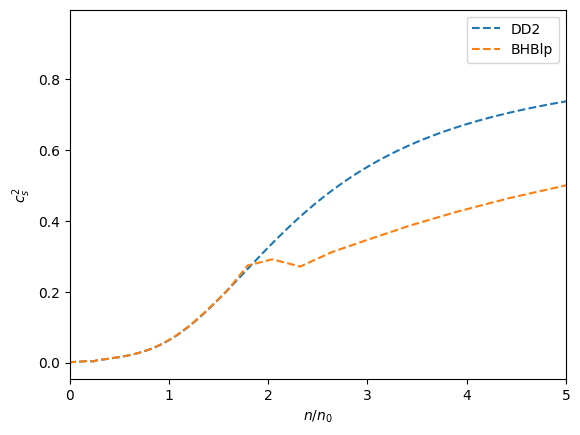

In [18]:

plt.plot(eos_dens['DD2']/n0,eos_cs2['DD2'],label='DD2',linestyle='--')  
plt.plot(eos_dens['BHBlp']/n0,eos_cs2['BHBlp'],label='BHBlp',linestyle='--')
# for alpha in RVSS_List:
#     plt.plot(RVSS_List[alpha][0].nb_unified/n0,RVSS_List[alpha][0].cs2_unified,label=f'Alpha {alpha}',color=RVSS_List[alpha][1])
plt.legend()
plt.xlim([0,5])
plt.xlabel(r'$n/n_0$')
plt.ylabel(r'$c_s^2$')
plt.show()

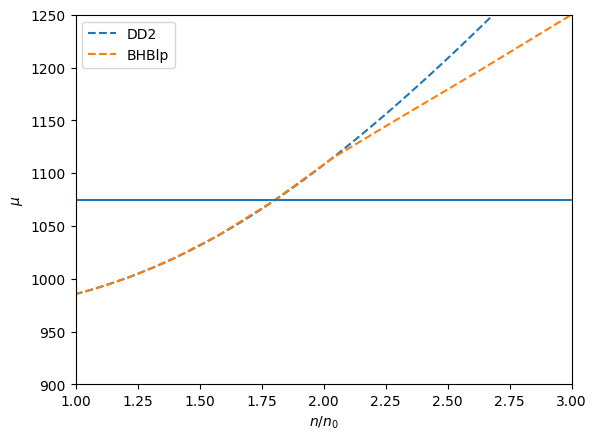

In [19]:

plt.plot(eos_dens['DD2']/n0,eos_mub['DD2'],label='DD2',linestyle='--')  
plt.plot(eos_dens['BHBlp']/n0,eos_mub['BHBlp'],label='BHBlp',linestyle='--')
# for alpha in RVSS_List:
#     plt.plot(RVSS_List[alpha][0].nb_unified/n0,RVSS_List[alpha][0].cs2_unified,label=f'Alpha {alpha}',color=RVSS_List[alpha][1])
plt.legend()
plt.xlim([1,3])
plt.ylim([900,1250])
plt.xlabel(r'$n/n_0$')
plt.ylabel(r'$\mu$')
plt.axhline(1075)
plt.show()

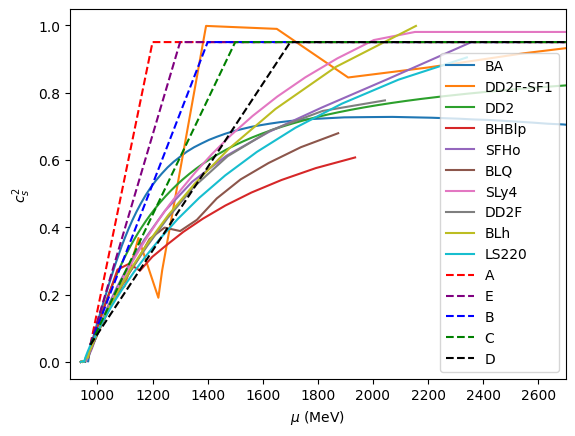

In [20]:
for eos in eos_list:
    if eos != 'SLy' and eos != 'MS1b':
        plt.plot(eos_mub[eos],eos_cs2[eos],label=eos)
for alpha in RVSS_List:
    plt.plot(RVSS_List[alpha][0].mub,RVSS_List[alpha][0].cs2_mub,label=f'{alpha}',color=RVSS_List[alpha][1],linestyle='--')
plt.legend()
plt.xlim([900,2700])
plt.xlabel(r'$\mu \text{ (MeV)}$')
plt.ylabel(r'$c_s^2$')
plt.savefig('./Figures/Final_Paper_Figs/cs2_mu.pdf',format='pdf')
plt.show()

In [18]:
RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz

RVSS_cs2_mu_c = {'V': [[RVSS_Mf2_list_1p3[0],NS_RVSS_cs2_c_interp['V'](1.3)/NS_RVSS_mub_c_interp['V'](1.3)],
                           [RVSS_Mf2_list_1p4[0],NS_RVSS_cs2_c_interp['V'](1.4)/NS_RVSS_mub_c_interp['V'](1.4)]],
                     'IV': [[RVSS_Mf2_list_1p35[0]]],
                     'III':[[RVSS_Mf2_list_1p3[1],NS_RVSS_cs2_c_interp['III'](1.3)/NS_RVSS_mub_c_interp['III'](1.3)],
                           [RVSS_Mf2_list_1p4[1],NS_RVSS_cs2_c_interp['III'](1.4)/NS_RVSS_mub_c_interp['III'](1.4)]],
                     'II': [[RVSS_Mf2_list_1p3[2],NS_RVSS_cs2_c_interp['II'](1.3)/NS_RVSS_mub_c_interp['II'](1.3)],
                           [RVSS_Mf2_list_1p4[2],NS_RVSS_cs2_c_interp['II'](1.4)/NS_RVSS_mub_c_interp['II'](1.4)]],
                     'I': [[RVSS_Mf2_list_1p3[3],NS_RVSS_cs2_c_interp['I'](1.3)/NS_RVSS_mub_c_interp['I'](1.3)],
                           [RVSS_Mf2_list_1p4[3],NS_RVSS_cs2_c_interp['I'](1.4)/NS_RVSS_mub_c_interp['I'](1.4)]]}



In [19]:
M_Rvss = [1.3,1.4,1.35]


for mass in M_Rvss:
    for model in RVSS_Solvers:
        p_central = NS_RVSS_pc_interp[model](mass)/epsilon
        sol_rvss = RVSS_Solvers[model].solve(p_central,dr=0.001,rmax=30,dr_max=0.01)
        rvss_nb_c = RVSS_List[model][0].nb_interp(p_central*epsilon)
        
        rvss_p_r = sol_rvss.y[0,:]*epsilon
        rvss_nb_r = RVSS_List[model][0].nb_interp(rvss_p_r)
        rvss_e_r = RVSS_List[model][0].eos_interp(rvss_p_r)
        rvss_cs2_r = RVSS_List[model][0].cs2_nb(rvss_nb_r)
        rvss_mub_r = (rvss_e_r + rvss_p_r)/(rvss_nb_r)

        rvss_nb_r_interp = interp1d(rvss_nb_r,sol_rvss.t)
        rvss_cs2_mub_r_interp = interp1d(sol_rvss.t,rvss_cs2_r/rvss_mub_r)

        r_stop_rvss = rvss_nb_r_interp((2.0/3.0)*rvss_nb_c)
        rvss_cs2_mub_avg = ns_vol_avg(rvss_cs2_mub_r_interp,sol_rvss,r_stop_rvss)
        
        print(model,rvss_nb_c,sol_rvss.y[1,-1],rvss_cs2_mub_avg)


V 0.2869994877898427 1.2973966576610583 0.00025348663151206696
III 0.4047328587680112 1.297388554900329 0.0002212067411101793
II 0.4774152995165428 1.2975914639176205 0.00021506348725374336
I 0.6768020467952401 1.2975594755030757 0.0002128952057388413
IV 0.34249383904357444 1.2976135549268037 0.00023224586576455283


/tmp/ipykernel_5089/3673447275.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Vol_avg_integral = quad(vol_avg_integrand,a=0,b=r_stop)[0]


V 0.29349185910210035 1.3973180431859806 0.0002763301718895791
III 0.42444530177530954 1.397405061227033 0.000243466428172657
II 0.5088045408899337 1.397371905542651 0.00023846299786844317
I 0.7569823961241926 1.397284508474011 0.0002424218455128544
IV 0.35432057366688524 1.3973632964407723 0.00025413721267224135
V 0.2902741149267925 1.3473503661931767 0.0002648243793516182
III 0.4145821293395322 1.3474966392848498 0.0002321938025920293
II 0.4929101098503652 1.3473754016087176 0.00022649801148265565
I 0.7153790380840013 1.347381004191469 0.0002270347266219422
IV 0.34842970706077886 1.3474987026455585 0.00024307912382504884


In [20]:
RVSS_cs2_mu_avg = {'A': [[RVSS_Mf2_list_1p3[0],0.00025229638098487727,1.3],
                           [RVSS_Mf2_list_1p4[0],0.00027500409991642444,1.4]],
                     'B': [[RVSS_Mf2_list_1p3[1],0.00022007376550508775,1.3],
                           [RVSS_Mf2_list_1p4[1],0.00024216057938415111,1.4]],
                     'C': [[RVSS_Mf2_list_1p3[2],0.00021387106648921783,1.3],
                           [RVSS_Mf2_list_1p4[2],0.00023707857153066288,1.4]],
                     'D': [[RVSS_Mf2_list_1p3[3],0.00021144421254325966,1.3],
                           [RVSS_Mf2_list_1p4[3],0.00024057289846845126,1.4]],
                     'E': [[RVSS_Mf2_list_1p3[4],0.00023224586576455283,1.3],
                           [RVSS_Mf2_list_1p35[0],0.00024307912382504884,1.35]],}

In [21]:
def marker_size(M):
    return 20*np.exp(M)

In [22]:
equal_mass_alpha_c = {}
equal_mass_cs2_mub_c = {}
equal_mass_cs2_mub_c_avg = {}
equal_mass_alpha_mub_avg = {}

for sim in sim_names:
    m1 = sim_info[sim]['m1']
    m2 = sim_info[sim]['m2']
    eos = sim_info[sim]['eos']
    
    if m1 == m2 and eos != 'MS1b' and eos != 'SLy':
        print(sim)
        ns_sol = solver_list[eos].solve(NS_pc_interp[eos](m1),dr=0.001,rmax=30,dr_max=0.01)
        ns_nbc = dens_interp[eos](ns_sol.y[0,0]*epsilon)
        ns_p_r = ns_sol.y[0,:]*epsilon
        ns_e_r = eos_interp[eos](ns_p_r)
        ns_nb_r = dens_interp[eos](ns_p_r)
        ns_mu_r = interp1d(ns_sol.t,(ns_e_r + ns_p_r)/ns_nb_r,fill_value='extrapolate')
      
        ns_nb_r_interp = interp1d(ns_nb_r,ns_sol.t)

        ns_rstop = ns_nb_r_interp((2.0/3.0)*ns_nbc)
        ns_cs2_r = interp1d(ns_sol.t,eos_cs2_interp[eos](ns_p_r)/ns_mu_r(ns_sol.t),fill_value='extrapolate')
        ns_alpha_r = interp1d(ns_sol.t,alpha_interp[eos](ns_p_r)*ns_mu_r(ns_sol.t),fill_value='extrapolate')

        cs2_mub_Vavg = ns_vol_avg(ns_cs2_r,ns_sol,ns_rstop)
        alpha_mub_Vavg = ns_vol_avg(ns_alpha_r,ns_sol,ns_rstop)

        if eos not in equal_mass_alpha_c.keys():
            equal_mass_alpha_c[eos] = [[float(NS_alpha_interp[eos](m1)),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2],]
            equal_mass_cs2_mub_c[eos] = [[float(NS_cs2_c_interp[eos](m1))/(NS_mub_c_interp[eos](m1)),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2],]
            equal_mass_cs2_mub_c_avg[eos] = [[float(cs2_mub_Vavg),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2],]
            equal_mass_alpha_mub_avg[eos] = [[float(alpha_mub_Vavg),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2],]
        else:
            equal_mass_alpha_c[eos].append([float(NS_alpha_interp[eos](m1)),(m1+m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2])
            equal_mass_cs2_mub_c[eos].append([float(NS_cs2_c_interp[eos](m1))/(NS_mub_c_interp[eos](m1)),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2])
            equal_mass_cs2_mub_c_avg[eos].append([float(cs2_mub_Vavg),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2])
            equal_mass_alpha_mub_avg[eos].append([float(alpha_mub_Vavg),(m1 + m2)*core_fpeak[sim]*1000/freq_code_u_to_hz,m1,m2])



SFHo_1.654_1.654_0.00_0.00_0.062_0.167_M0
SLy4_1.364_1.364_0.00_0.00_0.024_0.125_M0
SLy4_1.364_1.364_0.00_0.00_0.024_0.167_M0
SLy4_1.364_1.364_0.00_0.00_0.048_0.125_M0_LK
SLy4_1.364_1.364_0.00_0.00_0.048_0.167_M0_LK
SLy4_1.654_1.654_0.00_0.00_0.062_0.125_M0


/tmp/ipykernel_5089/3673447275.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Vol_avg_integral = quad(vol_avg_integrand,a=0,b=r_stop)[0]


SLy4_1.654_1.654_0.00_0.00_0.062_0.167_M0
BA_1.654_1.654_0.00_0.00_0.031_0.126


/tmp/ipykernel_5089/3673447275.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Vol_avg_integral = quad(vol_avg_integrand,a=0,b=r_stop)[0]


BA_1.654_1.654_0.00_0.00_0.031_0.167
BHBlp_1.250_1.250_0.00_0.00_0.050_0.125
BHBlp_1.300_1.300_0.00_0.00_0.053_0.125
BHBlp_1.350_1.350_0.00_0.00_0.055_0.083
BHBlp_1.350_1.350_0.00_0.00_0.055_0.125
BLh_1.654_1.654_0.00_0.00_0.062_0.125_M0
BLh_1.654_1.654_0.00_0.00_0.062_0.167_M0
BLQ_1.300_1.300_0.00_0.00_0.053_0.125_M0
BHBlp_1.364_1.364_0.00_0.00_0.048_0.167_M0_LK
BHBlp_1.400_1.400_0.00_0.00_0.058_0.083
BHBlp_1.400_1.400_0.00_0.00_0.058_0.125
BHBlp_1.500_1.500_0.00_0.00_0.064_0.125
BHBlp_1.600_1.600_0.00_0.00_0.070_0.125
BLh_1.300_1.300_0.00_0.00_0.053_0.125_M0
BHBlp_1.350_1.350_0.00_0.00_0.055_0.125_M0
BLh_1.300_1.300_0.00_0.00_0.053_0.167_M0
BLQ_1.300_1.300_0.00_0.00_0.053_0.167_M0
LS220_1.364_1.364_0.00_0.00_0.048_0.125_M0_LK
SFHo_1.350_1.350_0.00_0.00_0.055_0.167
SFHo_1.654_1.654_0.00_0.00_0.062_0.125_M0
BLh_1.333_1.333_0.00_0.00_0.054_0.125_M0
BLh_1.333_1.333_0.00_0.00_0.054_0.167_M0
BLh_1.364_1.364_0.00_0.00_0.048_0.083_M0
BLh_1.364_1.364_0.00_0.00_0.048_0.083_M0_LK
BLh_1.364_1.36

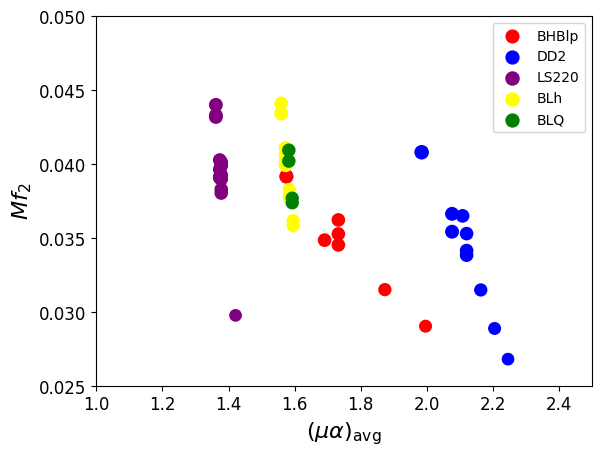

In [23]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_for_lin_reg):
    alpha_mu_avg,mf2,m1,m2 = zip(*equal_mass_alpha_mub_avg[eos])
    marker_sizes = np.vectorize(marker_size)(m1)
    np.savetxt(f'./Figure_Data/CORE/MF2_mu_cs2prime/{eos}_mu_cs2p_CORE.txt',equal_mass_alpha_mub_avg[eos])
    #C = (1.47*(np.asarray(m1) + np.asarray(m2)))/(NS_radius_interp[eos](m1) + NS_radius_interp[eos](m2))
    plt.scatter(np.asarray(alpha_mu_avg),mf2,label=f'{eos}',s=marker_sizes,color=eos_colors[i])


plt.ylabel(r'$Mf_2$')
plt.xlabel(r'$(\mu\alpha)_{\text{avg}}$')
plt.ylim([0.025,0.05])
plt.xlim([1.0,2.5])
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
# plt.savefig('Figures/MF2_Plots/Mf2_mu_alpha_C_4.pdf',format='pdf')
plt.show()

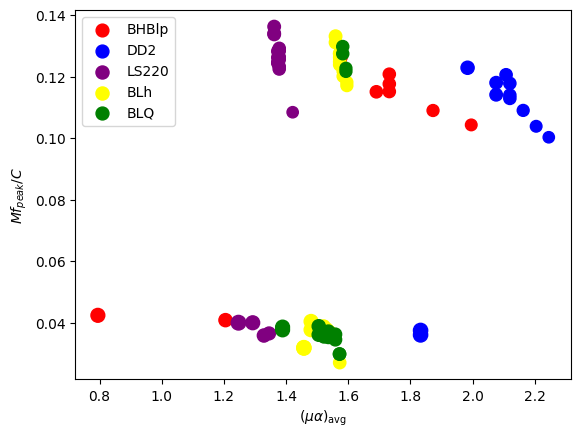

In [18]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_for_lin_reg):
    alpha_mu_avg,mf2,m1,m2 = zip(*equal_mass_alpha_mub_avg[eos])
    marker_sizes = np.vectorize(marker_size)(m1)
    C = (1.47*(np.asarray(m1) + np.asarray(m2)))/(NS_radius_interp[eos](m1))
    plt.scatter(np.asarray(alpha_mu_avg),mf2/C,label=f'{eos}',s=marker_sizes,color=eos_colors[i])
    

plt.ylabel(r'$Mf_{peak}/C$')
plt.xlabel(r'$(\mu\alpha)_{\text{avg}}$')
#plt.ylim([0.03,0.05])
#plt.xlim([0,0.0020])
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.savefig('./Figures/T2 Seminar Figs/Mf2_C_mu_alpha_avg.pdf',format='pdf')
plt.show()

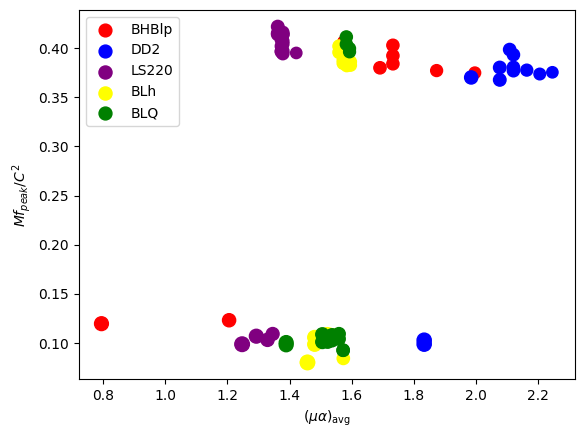

In [19]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_for_lin_reg):
    alpha_mu_avg,mf2,m1,m2 = zip(*equal_mass_alpha_mub_avg[eos])
    marker_sizes = np.vectorize(marker_size)(m1)
    C = (1.47*(np.asarray(m1) + np.asarray(m2)))/(NS_radius_interp[eos](m1))
    plt.scatter(np.asarray(alpha_mu_avg),mf2/C**2,label=f'{eos}',s=marker_sizes,color=eos_colors[i])
    

plt.ylabel(r'$Mf_{peak}/C^2$')
plt.xlabel(r'$(\mu\alpha)_{\text{avg}}$')
#plt.ylim([0.03,0.05])
#plt.xlim([0,0.0020])
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.savefig('./Figures/T2 Seminar Figs/Mf2_C2_mu_alpha_avg.pdf',format='pdf')
plt.show()

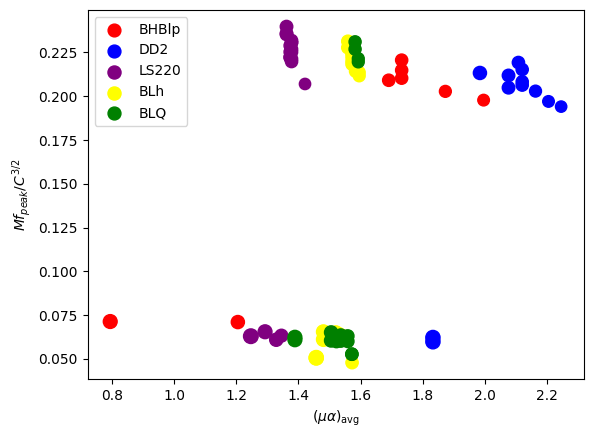

In [20]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_for_lin_reg):
    alpha_mu_avg,mf2,m1,m2 = zip(*equal_mass_alpha_mub_avg[eos])
    marker_sizes = np.vectorize(marker_size)(m1)
    C = (1.47*(np.asarray(m1) + np.asarray(m2)))/(NS_radius_interp[eos](m1))
    plt.scatter(np.asarray(alpha_mu_avg),mf2/C**(1.5),label=f'{eos}',s=marker_sizes,color=eos_colors[i])
    

plt.ylabel(r'$Mf_{peak}/C^{3/2}$')
plt.xlabel(r'$(\mu\alpha)_{\text{avg}}$')
#plt.ylim([0.03,0.05])
#plt.xlim([0,0.0020])
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.savefig('./Figures/T2 Seminar Figs/Mf2_C1p5_mu_alpha_avg.pdf',format='pdf')
plt.show()

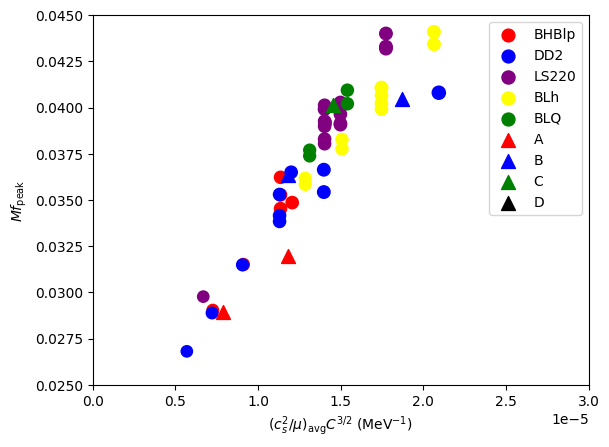

In [23]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(np.asarray(m1) + np.asarray(m2))/(NS_radius_interp[eos](m1) + NS_radius_interp[eos](m2))
    plt.scatter(C1**6,f2,label=eos,s=marker_sizes,color = eos_colors[i])
    #plt.scatter(cs2_mub_avg,f2,label=eos,s=marker_sizes,color = eos_colors[i])
for model in RVSS_cs2_mu_avg.keys():
    mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
    m = np.asarray(m)
    C_rvss = (1.47)*(2*m)/(2*NS_RVSS_radius_interp[model](m))
    
    plt.scatter(C_rvss**(6),mf2,label=model,marker='^',color=RVSS_List[model][1],s=100)
plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} C^{3/2} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.025,0.045])
plt.xlim([0,3*10**(-5)])
plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_C_cs2_mub_avg.pdf',format='pdf')


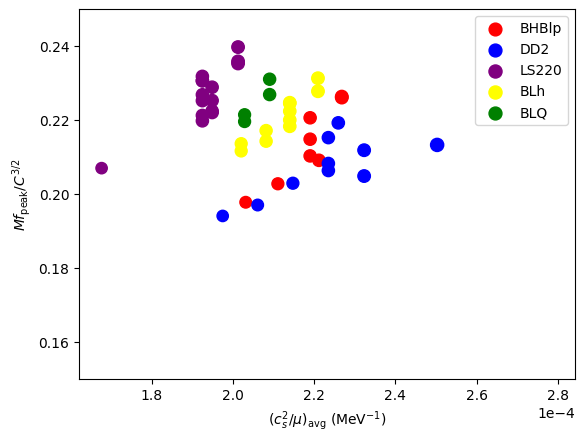

In [40]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(m_tot)/NS_radius_interp[eos](m1)

    plt.scatter(cs2_mub_avg,f2*C1**(-1.5),label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     m = np.asarray(m)
#     C_rvss = (1.47)*(2*m)/(NS_RVSS_radius_interp[model](m))
    
#     plt.scatter(cs2_mub_avg,mf2/C_rvss**(1.5),label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}/C^{3/2}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.150,0.25])
plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_C1p5_cs2_mub_avg.pdf',format='pdf')


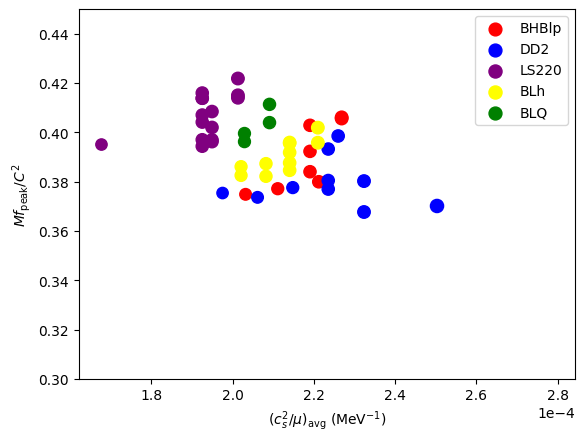

In [35]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(m_tot)/NS_radius_interp[eos](m1)

    plt.scatter(cs2_mub_avg,f2*C1**(-2),label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     m = np.asarray(m)
#     C_rvss = (1.47)*(2*m)/(NS_RVSS_radius_interp[model](m))
    
#     plt.scatter(cs2_mub_avg,mf2/C_rvss**2,label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}/C^{2}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.30,0.45])
plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_C2_cs2_mub_avg.pdf',format='pdf')

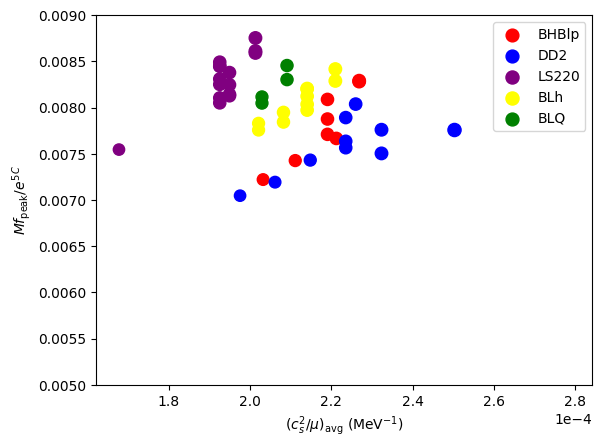

In [34]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(np.asarray(m_tot))/NS_radius_interp[eos](m1)

    plt.scatter(cs2_mub_avg,f2*np.exp(-5*C1),label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     m = np.asarray(m)
#     C_rvss = (1.47)*(2*m)/(NS_RVSS_radius_interp[model](m))
    
#     plt.scatter(cs2_mub_avg,mf2*np.exp(-5*C_rvss),label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}/e^{5C}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.ylim([0.005,0.009])
plt.legend()

(0.02, 0.045)

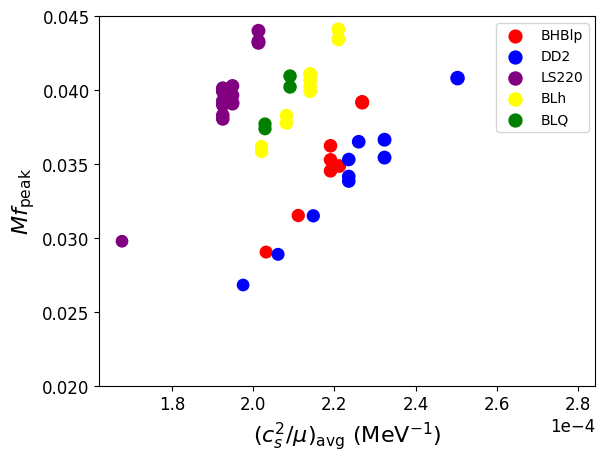

In [ ]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(m_tot)/NS_radius_interp[eos](m1)

    np.savetxt(f'./Figure_Data/CORE/Mf2_cs2_mu/{eos}_cs2_mu.txt',equal_mass_cs2_mub_c_avg[eos])

    plt.scatter(cs2_mub_avg,f2,label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     plt.scatter(cs2_mub_avg,mf2,label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.020,0.045])
# plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_vs_cs2_mub_avg.pdf',format='pdf')



(0.02, 0.045)

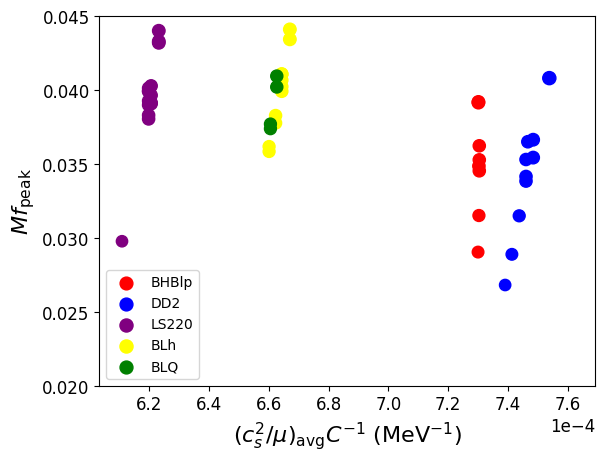

In [39]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(m_tot)/NS_radius_interp[eos](m1)

    np.savetxt(f'./Figure_Data/CORE/Mf2_cs2_mu/{eos}_cs2_mu_C.txt',cs2_mub_avg/C1)

    plt.scatter(cs2_mub_avg/C1**1,f2,label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     plt.scatter(cs2_mub_avg,mf2,label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} C^{-1} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.020,0.045])
# plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_vs_cs2_mub_avg.pdf',format='pdf')



(0.02, 0.045)

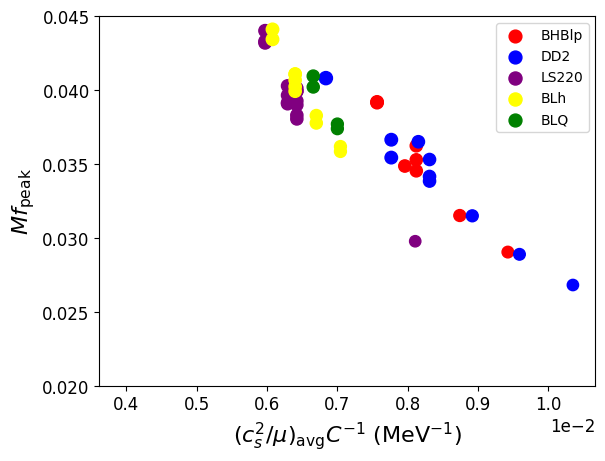

In [43]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(m_tot)/NS_radius_interp[eos](m1)

    np.savetxt(f'./Figure_Data/CORE/Mf2_cs2_mu/{eos}_cs2_mu_Cm3.txt',np.column_stack([cs2_mub_avg/C1**3,f2]))

    plt.scatter(cs2_mub_avg/C1**3,f2,label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     plt.scatter(cs2_mub_avg,mf2,label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} C^{-1} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.020,0.045])
# plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_vs_cs2_mub_avg.pdf',format='pdf')



(0.02, 0.045)

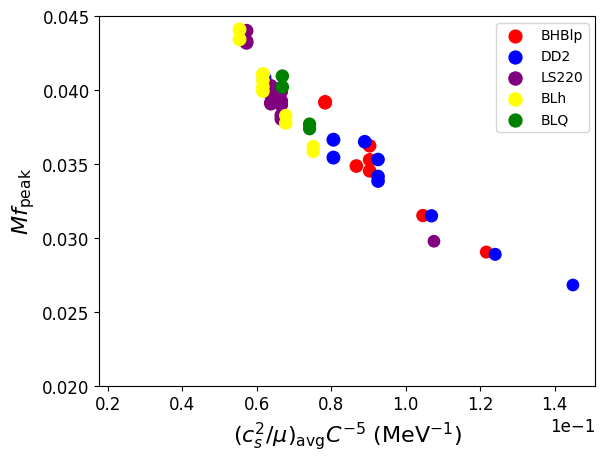

In [44]:
eos_for_lin_reg = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_colors = ["red","blue","purple","yellow","green"]
for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,f2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    marker_sizes= np.vectorize(marker_size)(m1)
    m_tot = np.asarray(m1) + np.asarray(m2)
    C1 = 1.47*(m_tot)/NS_radius_interp[eos](m1)

    np.savetxt(f'./Figure_Data/CORE/Mf2_cs2_mu/{eos}_cs2_mu_Cm5.txt',np.column_stack([cs2_mub_avg/C1**5,f2]))

    plt.scatter(cs2_mub_avg/C1**5,f2,label=eos,s=marker_sizes,color = eos_colors[i])
# for model in RVSS_cs2_mu_avg.keys():
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     plt.scatter(cs2_mub_avg,mf2,label=model,marker='^',color=RVSS_List[model][1],s=60)
plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} C^{-5} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.020,0.045])
# plt.savefig('./Figures/Final_Paper_Figs/Mfpeak_vs_cs2_mub_avg.pdf',format='pdf')



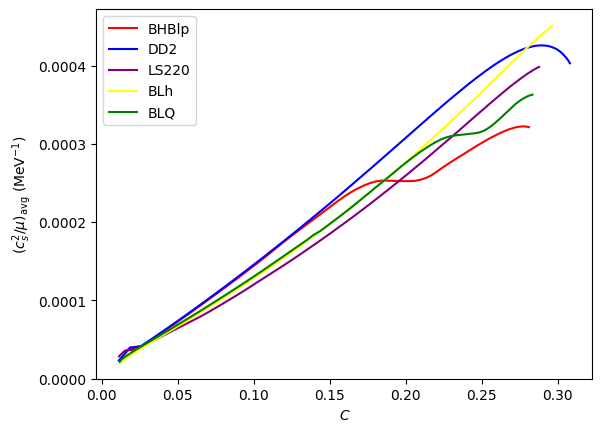

In [92]:
for i,eos in enumerate(eos_for_lin_reg):
    plt.plot((1.47)*NS_mass[eos]/NS_radius[eos],NS_cs2_mub_vavg[eos],color = eos_colors[i],label = eos)
    
# for model in RVSS_List:
#     mf2,cs2_mub_avg,m = zip(*RVSS_cs2_mu_avg[model])
#     plt.plot((1.47)*NS_Alpha_Mass[model]/NS_Alpha_Radius[model],NS_RVSS_mub_c_interp,color=RVSS_List[model][1])
plt.xlabel(r"$C$")
plt.ylabel(r"$(c_s^2/\mu)_{\text{avg}} \text{ (MeV}^{-1})$")
plt.legend()
plt.savefig('./Figures/T2 Seminar Figs/cs2_mu_C.pdf',format='pdf')

BHBlp 428.39534434760895 -0.05853323903711402 40.66779707793073 0.008881883400127797
DD2 270.38539321098295 -0.026305830850047292 20.253892119390816 0.004525137995798972
LS220 402.49842995714613 -0.038252101527819736 28.431670746806088 0.005498804970365973
BLh 412.08356445900415 -0.047513208163262315 22.58947283680303 0.004792116715333818
BLQ 492.13383431545424 -0.062313243343250425 65.01495293027753 0.013393656848857738


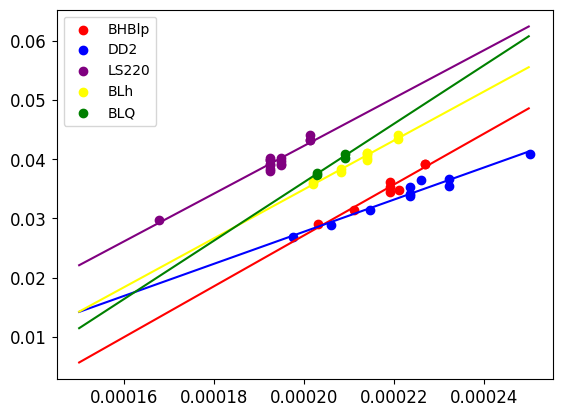

In [24]:

equal_mass_cs2_mu_avg_trim = {}
lin_fit = {}

for eos in eos_for_lin_reg:
    cs2_mub_avg,mf2,m1,m2 = zip(*equal_mass_cs2_mub_c_avg[eos])
    equal_mass_cs2_mu_avg_trim[eos] = list()
    for i,mf in enumerate(mf2):
        if mf > 0.020:
            equal_mass_cs2_mu_avg_trim[eos].append([cs2_mub_avg[i],mf])

for i,eos in enumerate(eos_for_lin_reg):
    cs2_mub_avg,mf2 = zip(*equal_mass_cs2_mu_avg_trim[eos])
    lin_fit[eos] = linregress(cs2_mub_avg,mf2)
    cs2_mub_lin = np.linspace(0.00015,0.00025,100)
    mf2_lin = lin_fit[eos].slope*cs2_mub_lin + lin_fit[eos].intercept
    plt.plot(cs2_mub_lin,mf2_lin,color=eos_colors[i])
    plt.scatter(cs2_mub_avg,mf2,label=eos,color=eos_colors[i])
    print(eos,lin_fit[eos].slope,lin_fit[eos].intercept,lin_fit[eos].stderr,lin_fit[eos].intercept_stderr)
plt.legend()



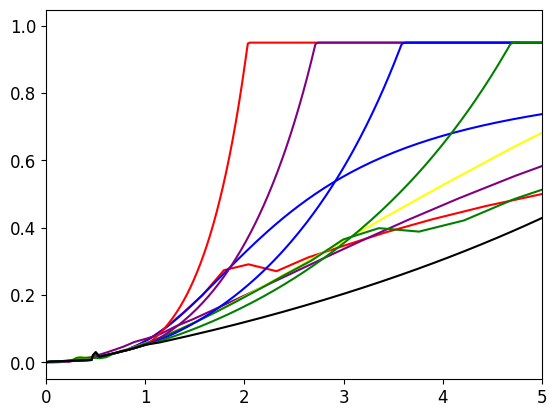

In [25]:
for i,eos in enumerate(eos_for_lin_reg):
    plt.plot(eos_dens[eos]/n0,eos_cs2[eos],color = eos_colors[i],label=eos)
    plt.xlim([0,5])
for model in RVSS_List:
    plt.plot(RVSS_List[model][0].nb_unified/n0,RVSS_List[model][0].cs2_unified,color=RVSS_List[model][1])

In [34]:
for sim in sim_info.keys():
    if sim_info[sim]['eos'] == 'MS1b' or sim_info[sim]['eos'] == 'SLy': continue
    eos = sim_info[sim]['eos']
    m1 = sim_info[sim]['m1']
    m2 = sim_info[sim]['m2']

    ejecta_h5_files = glob.glob(os.path.abspath(os.path.join(core_db_path,sim,'ejecta','*.h5')))
    ejecta_vinf_files = glob.glob(os.path.abspath(os.path.join(core_db_path,sim,'ejecta','hist_vel_inf_det*.txt')))
    if not ejecta_h5_files:
        continue
    else:
        with h5.File(ejecta_h5_files[0]) as ejecta_file:
            sim_info[sim]['M_ejecta_norm'] = np.sum(ejecta_file['mass'])/(m1 + m2)
        
    EJ_file = glob.glob(os.path.abspath(os.path.join(core_db_path,sim,'waveforms','EJ_r00400.txt')))
    if not EJ_file:
        print(sim)
        continue
    EJ_data = np.loadtxt(EJ_file[0],skiprows=3)
    sim_info[sim]['E_GW_Norm'] = EJ_data[-1,3]/(m1 + m2)
    sim_info[sim]['J_GW_Norm'] = EJ_data[-1,4]/(m1 + m2)**2
    
    ns_cs2_mub_vavg_1 = NS_m_cs2_mub_vavg_interp[eos](m1)
    ns_cs2_mub_vavg_2 = NS_m_cs2_mub_vavg_interp[eos](m2)

    ns_alpha_mu_vavg1 = NS_m_alpha_mu_vavg_interp[eos](m1)
    ns_alpha_mu_vavg2 = NS_m_alpha_mu_vavg_interp[eos](m2)

    ns_cs2_vavg_1 = NS_cs2_vavg_interp[eos](m1)
    ns_cs2_vavg_2 = NS_cs2_vavg_interp[eos](m2)

    compactness_1 = (1.47)*(m1/NS_radius_interp[eos](m1))
    compactness_2 = (1.47)*(m2/NS_radius_interp[eos](m2))

    sim_info[sim]['cs2_mub_vavg'] = np.average([ns_cs2_mub_vavg_1,ns_cs2_mub_vavg_2])
    sim_info[sim]['avg_compactness'] = np.average([compactness_1,compactness_2])
    sim_info[sim]['ns_alpha_mu_vavg'] = np.average([ns_alpha_mu_vavg1,ns_alpha_mu_vavg2])
    sim_info[sim]['ns_cs2_vavg'] = np.average([ns_cs2_vavg_1,ns_cs2_vavg_2])
    
    

BHBlp_1.364_1.364_0.00_0.00_0.048_0.167_M0_LK


In [28]:
sims_for_corner = [sim for sim,info in sim_info.items() if ('M_ejecta_norm' in info and 'J_GW_Norm' in info and 'Mfpeak' in info)]

In [29]:
print(sims_for_corner)

['SFHo_1.654_1.654_0.00_0.00_0.062_0.167_M0', 'SLy4_1.364_1.364_0.00_0.00_0.024_0.125_M0', 'SLy4_1.364_1.364_0.00_0.00_0.024_0.167_M0', 'SLy4_1.364_1.364_0.00_0.00_0.048_0.125_M0_LK', 'SLy4_1.364_1.364_0.00_0.00_0.048_0.167_M0_LK', 'SLy4_1.437_1.914_0.00_0.00_0.063_0.125_M0', 'SLy4_1.437_1.914_0.00_0.00_0.063_0.167_M0', 'SLy4_1.452_1.283_0.00_0.00_0.048_0.125_M0', 'SLy4_1.527_1.795_0.00_0.00_0.063_0.125_M0', 'SLy4_1.527_1.795_0.00_0.00_0.063_0.167_M0', 'SLy4_1.635_1.146_0.00_0.00_0.049_0.125_M0_LK', 'SLy4_1.654_1.654_0.00_0.00_0.062_0.125_M0', 'SLy4_1.654_1.654_0.00_0.00_0.062_0.167_M0', 'SLy4_1.772_1.065_0.00_0.00_0.050_0.125_M0_LK', 'SLy4_1.772_1.065_0.00_0.00_0.050_0.167_M0_LK', 'SLy4_1.856_1.020_0.00_0.00_0.051_0.167_M0_LK', 'BHBlp_1.250_1.250_0.00_0.00_0.050_0.125', 'BHBlp_1.300_1.300_0.00_0.00_0.053_0.125', 'BHBlp_1.350_1.350_0.00_0.00_0.055_0.083', 'BHBlp_1.350_1.350_0.00_0.00_0.055_0.125', 'BLh_1.654_1.654_0.00_0.00_0.062_0.125_M0', 'BLh_1.654_1.654_0.00_0.00_0.062_0.167_M0', '

In [30]:
M_ej_normalized = [sim_info[sim]['M_ejecta_norm'] for sim in sims_for_corner]
E_gw_normalized = [sim_info[sim]['E_GW_Norm'] for sim in sims_for_corner]
J_gw_normalized = [sim_info[sim]['J_GW_Norm'] for sim in sims_for_corner]
cs2_mub_avg_core = [sim_info[sim]['cs2_mub_vavg'] for sim in sims_for_corner]
alpha_mu_avg_core = [sim_info[sim]['ns_alpha_mu_vavg'] for sim in sims_for_corner]
mf2_core = [sim_info[sim]['Mfpeak'] for sim in sims_for_corner]
avg_compactness = [sim_info[sim]['avg_compactness'] for sim in sims_for_corner]
cs2_vavg = [sim_info[sim]['ns_cs2_vavg'] for sim in sims_for_corner]


In [31]:
corner_plot_data = np.vstack((M_ej_normalized,
                              E_gw_normalized,
                              J_gw_normalized,
                              cs2_mub_avg_core,
                              cs2_vavg,
                              alpha_mu_avg_core,
                              mf2_core,
                              avg_compactness))
labels = [
    r"$M_{\text{ej}}/(M_1 + M_2)$",
    r"$E_{\text{GW}}/(M_1 + M_2)$",
    r"$J_{\text{GW}}/(M_1 + M_2)^2$",
    r"$(c_s^2/\mu)_{\text{avg}}$",
    r"$(c_s^2)_{\text{avg}}$",
    r"$(\mu\alpha)_{\text{avg}}$",
    r"$(M_1 + M_2)f_2$",
    r"$C_{avg}$"
]

In [32]:
print(len(labels))

8


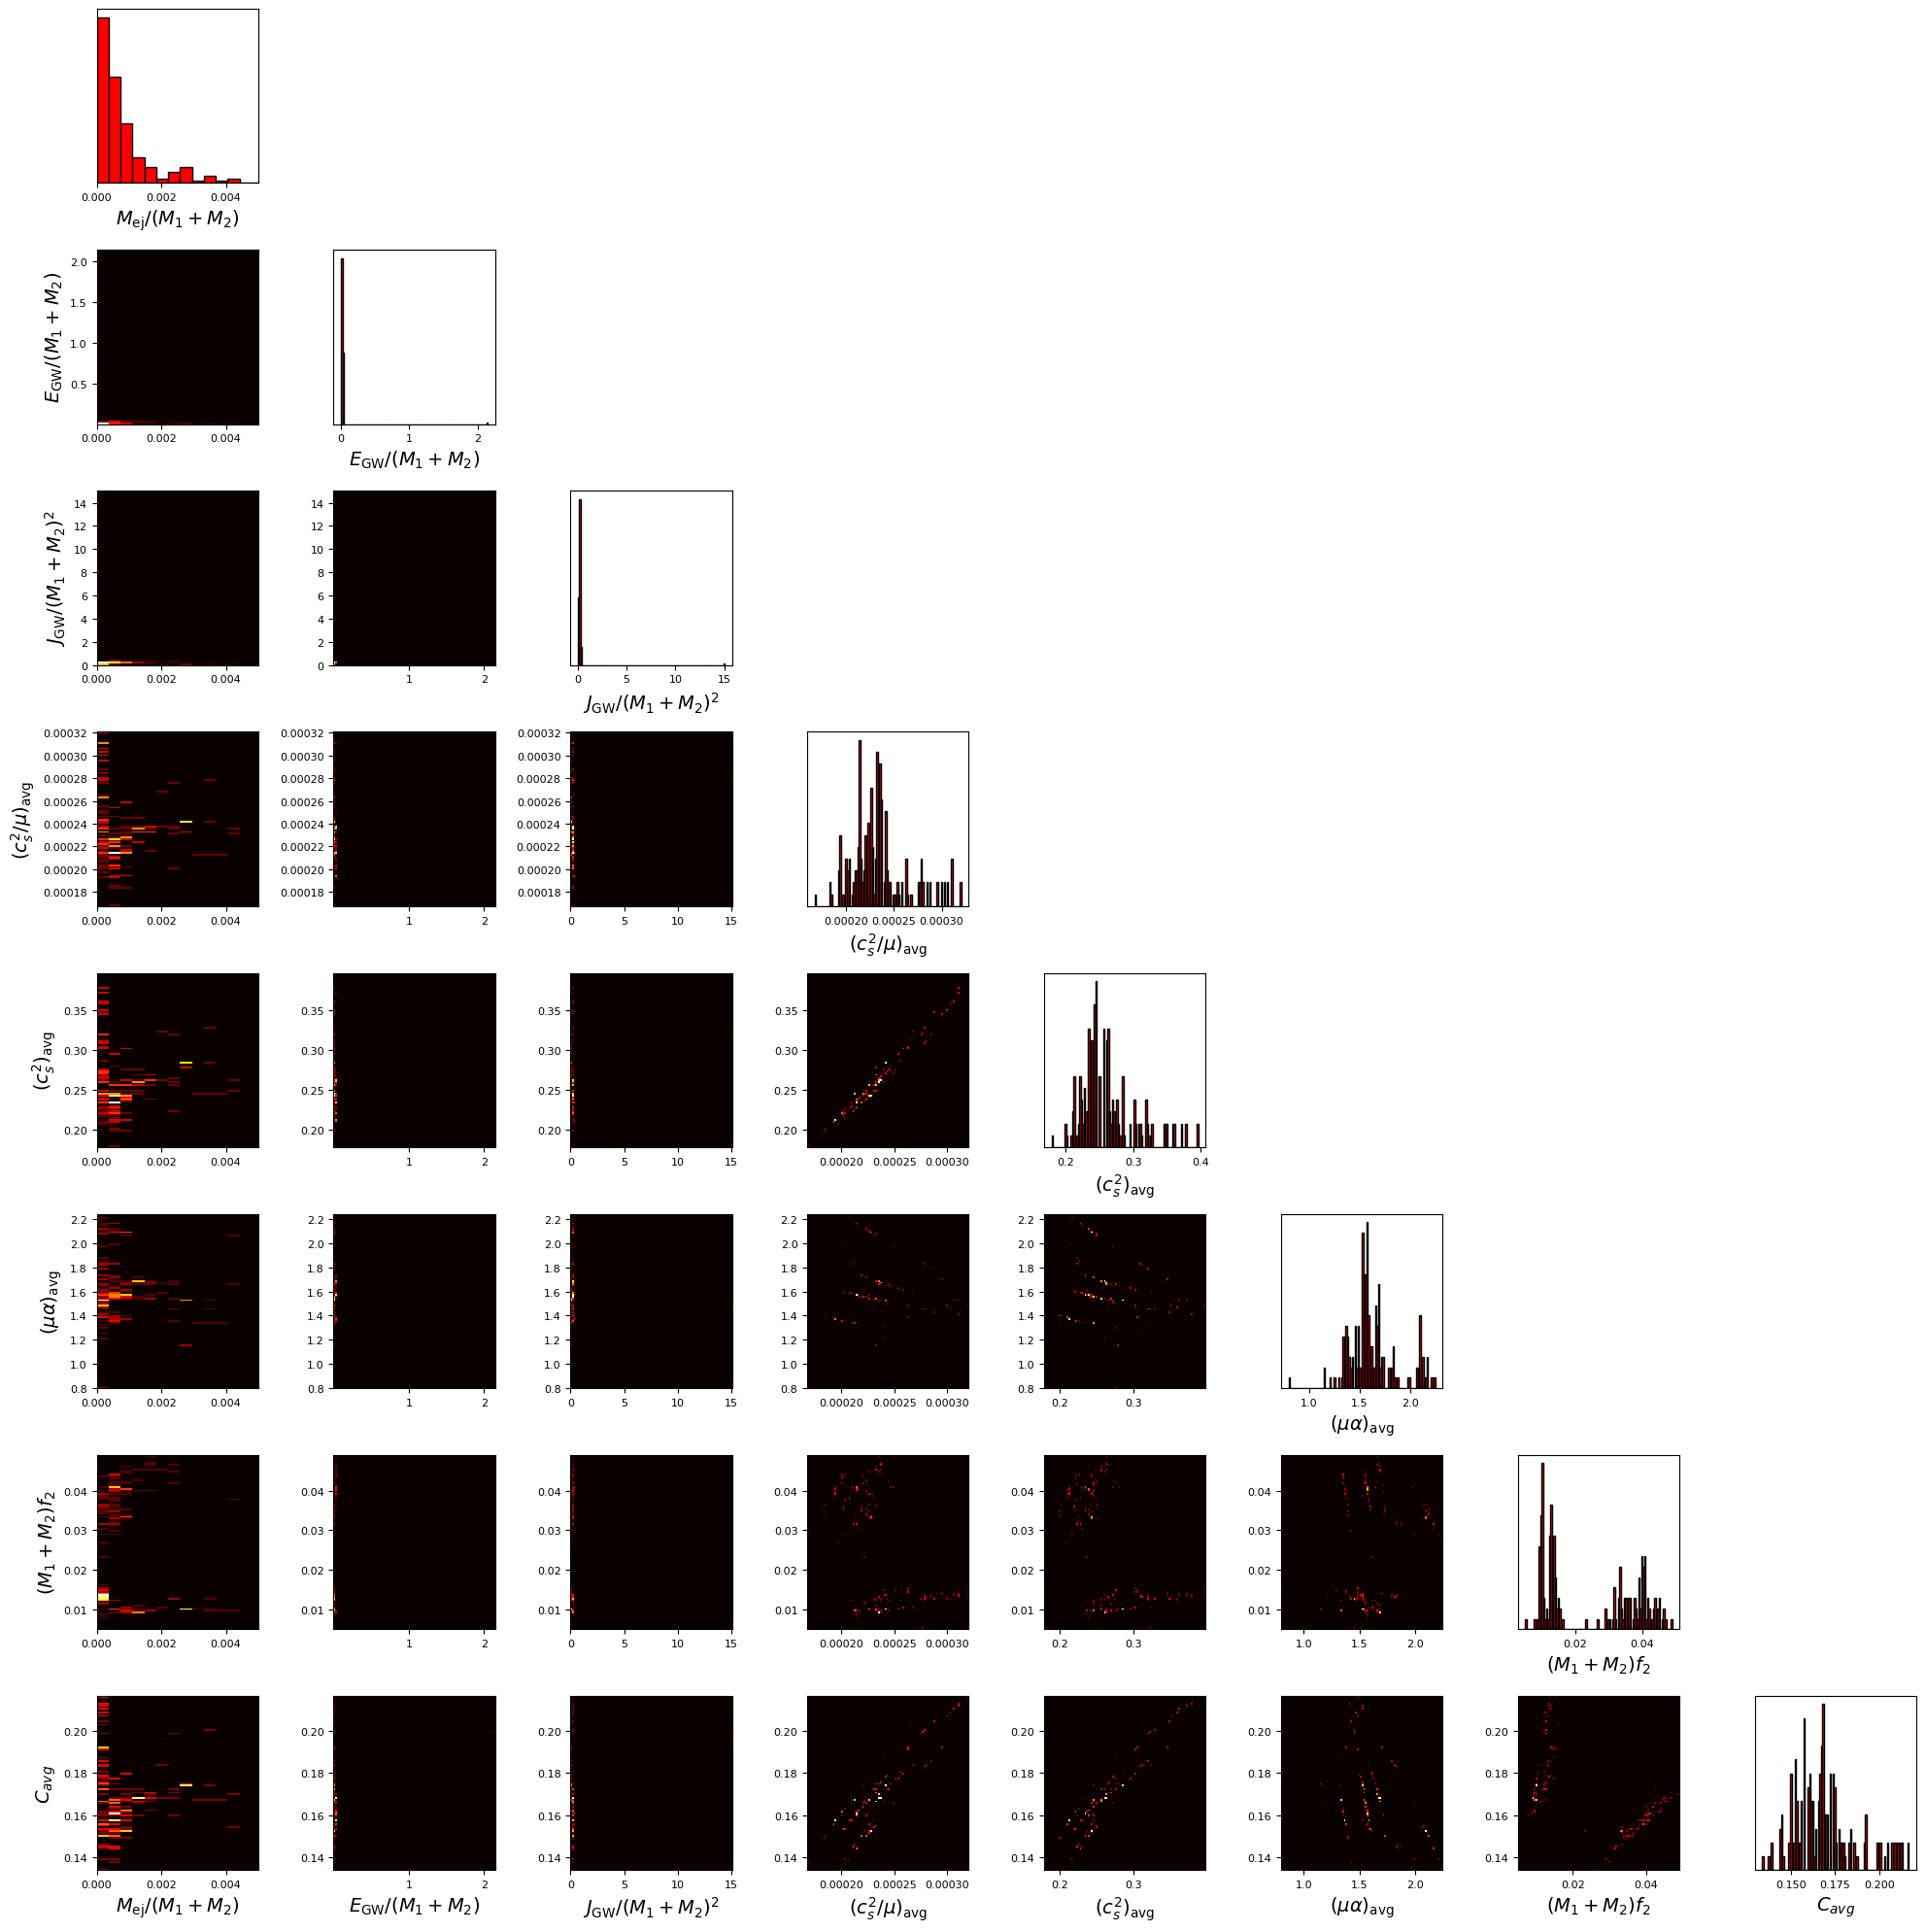

In [33]:
nvars = 8
n_bins = 100

fig,axes = plt.subplots(nvars,nvars,figsize=(20,20))

for i in range(nvars):
    for j in range(nvars):
        ax = axes[i,j]
        
        if i == j:
            ax.hist(corner_plot_data[i,:],bins=n_bins,density=True,
                    color = 'red',edgecolor='black')
            ax.set_xlabel(labels[i],fontsize=14)
            ax.set_yticks([])
        elif i > j:
            ax.hist2d(corner_plot_data[j,:],corner_plot_data[i,:],bins=n_bins,cmap='hot')
            if j == 0:
                ax.set_ylabel(labels[i],fontsize=14)
            if i == nvars-1:
                ax.set_xlabel(labels[j],fontsize=14)
        else:
            ax.set_visible(False)
        if j == 0:
            ax.set_xlim([0,0.005])
        ax.tick_params(axis='both',labelsize=8)

plt.tight_layout()
# plt.savefig('Figures/T2 Seminar Figs/corner_plot.pdf',format = 'pdf')